Loaded adjacency matrix of shape: (64, 64)


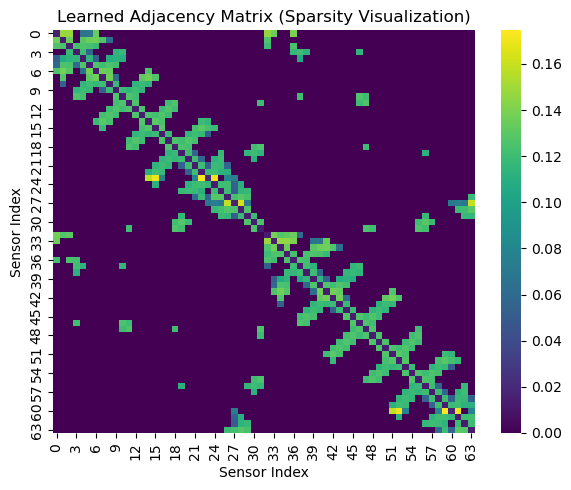

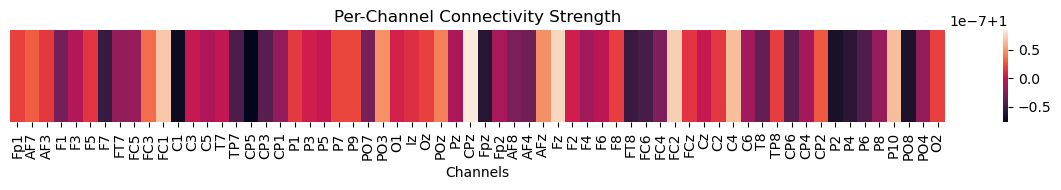

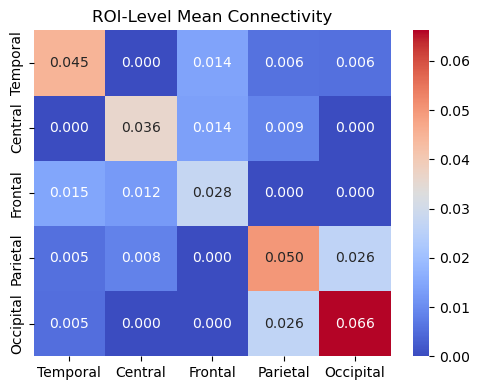

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

# -------------------------------------------------------
# LOAD ADJACENCY MATRIX FROM CSV (NO HEADERS)
# -------------------------------------------------------
A = pd.read_csv("A_final.csv", header=None).values

assert A.shape[0] == A.shape[1], "Matrix must be square."

N = A.shape[0]
print("Loaded adjacency matrix of shape:", A.shape)

# -------------------------------------------------------
# PROVIDE CHANNEL NAMES IN ORDER (64 OR 128)
# Replace with your exact montage order.
# Example below uses a BioSemi64-like order.
# -------------------------------------------------------
montage = mne.channels.make_standard_montage("biosemi64")
channel_names = montage.ch_names
if len(channel_names) != N:
    print("⚠️ Channel name count does not match matrix size.")
    print(f"Matrix size = {N}, but channel list has {len(channel_names)} items.")
    print("Proceeding anyway with generic labels.")
    channel_names = [f"Ch{i+1}" for i in range(N)]

# Build index lookup
ch_to_idx = {name:i for i,name in enumerate(channel_names)}

# -------------------------------------------------------
# ROI GROUPS (EDIT IF NEEDED)
# -------------------------------------------------------
rois = {
    "Temporal": ["T7","T8","TP7","TP8","FT7","FT8"],
    "Central": ["Cz","C3","C4","CPz","FC1","FC2"],
    "Frontal": ["F3","F4","F7","F8","Fz","AFz"],
    "Parietal": ["P3","P4","Pz","P1","P2","P5","P6"],
    "Occipital": ["O1","O2","Oz","PO3","PO4","PO7","PO8"]
}

# -------------------------------------------------------
# FIGURE 1: FULL ADJACENCY MATRIX (SPARSITY)
# -------------------------------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(A, cmap="viridis", cbar=True)
plt.title("Learned Adjacency Matrix (Sparsity Visualization)")
plt.xlabel("Sensor Index")
plt.ylabel("Sensor Index")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# FIGURE 2: NODE STRENGTH HEATMAP (CENTRO-TEMPORAL DOMINANCE)
# -------------------------------------------------------
node_strength = A.sum(axis=1)  # outgoing weights

plt.figure(figsize=(12,2))
sns.heatmap(node_strength.reshape(1, -1),
            cmap="rocket", cbar=True,
            xticklabels=channel_names)
plt.yticks([])
plt.title("Per-Channel Connectivity Strength")
plt.xlabel("Channels")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# FIGURE 3: ROI-TO-ROI CONNECTIVITY HEATMAP
# -------------------------------------------------------
roi_labels = list(rois.keys())
roi_matrix = np.zeros((len(roi_labels), len(roi_labels)))

for i, roi1 in enumerate(roi_labels):
    for j, roi2 in enumerate(roi_labels):
        idx1 = [ch_to_idx[ch] for ch in rois[roi1] if ch in ch_to_idx]
        idx2 = [ch_to_idx[ch] for ch in rois[roi2] if ch in ch_to_idx]
        if idx1 and idx2:
            roi_matrix[i,j] = A[np.ix_(idx1, idx2)].mean()
        else:
            roi_matrix[i,j] = 0

plt.figure(figsize=(5,4))
sns.heatmap(roi_matrix, annot=True, cmap="coolwarm",
            xticklabels=roi_labels, yticklabels=roi_labels,
            fmt=".3f")
plt.title("ROI-Level Mean Connectivity")
plt.tight_layout()
plt.show()


In [ ]:
channel_names = [
    "Fp1","Fp2","F3","F4","C3","C4","P3","P4","O1","O2",
    "F7","F8","T7","T8","P7","P8","Fz","Cz","Pz","Oz",
    "FC1","FC2","CP1","CP2","FC5","FC6","CP5","CP6",
    "TP7","TP8","FT7","FT8","POz","CPz","AFz","P1",
    "P2","PO3","PO4","O9","O10","T9","T10","Iz",
    "F1","F2","C1","C2","P1","P2","FC3","FC4",
    "CP3","CP4","PO7","PO8","AF3","AF4","F5","F6","P5","P6"
]
len(channel_names)

62

In [9]:
channel_names

['Fp1',
 'AF7',
 'AF3',
 'F1',
 'F3',
 'F5',
 'F7',
 'FT7',
 'FC5',
 'FC3',
 'FC1',
 'C1',
 'C3',
 'C5',
 'T7',
 'TP7',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'P9',
 'PO7',
 'PO3',
 'O1',
 'Iz',
 'Oz',
 'POz',
 'Pz',
 'CPz',
 'Fpz',
 'Fp2',
 'AF8',
 'AF4',
 'AFz',
 'Fz',
 'F2',
 'F4',
 'F6',
 'F8',
 'FT8',
 'FC6',
 'FC4',
 'FC2',
 'FCz',
 'Cz',
 'C2',
 'C4',
 'C6',
 'T8',
 'TP8',
 'CP6',
 'CP4',
 'CP2',
 'P2',
 'P4',
 'P6',
 'P8',
 'P10',
 'PO8',
 'PO4',
 'O2']

Loaded adjacency matrix of shape: (64, 64)


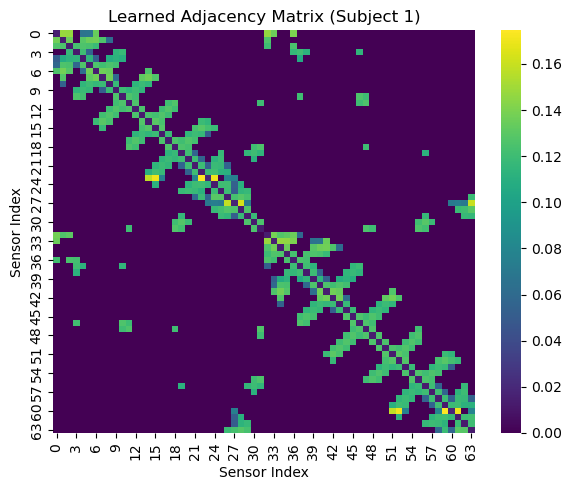

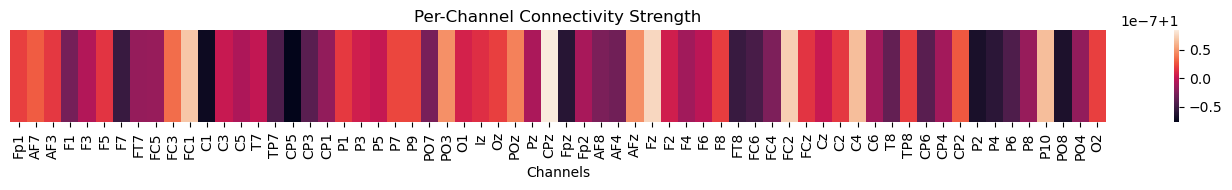

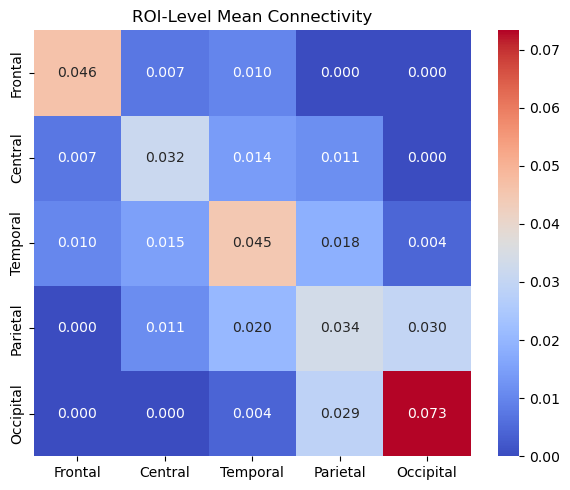

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------
# LOAD ADJACENCY MATRIX FROM CSV (NO HEADERS)
# -------------------------------------------------------
A = pd.read_csv("A_final.csv", header=None).values
assert A.shape[0] == A.shape[1], "Matrix must be square."

N = A.shape[0]
print("Loaded adjacency matrix of shape:", A.shape)

# -------------------------------------------------------
# YOUR EXACT 64 BIOSEMI CHANNEL NAMES (ORDER PRESERVED)
# -------------------------------------------------------
channel_names = [
 'Fp1','AF7','AF3','F1','F3','F5','F7','FT7','FC5','FC3','FC1','C1','C3','C5','T7',
 'TP7','CP5','CP3','CP1','P1','P3','P5','P7','P9','PO7','PO3','O1','Iz','Oz','POz',
 'Pz','CPz','Fpz','Fp2','AF8','AF4','AFz','Fz','F2','F4','F6','F8','FT8','FC6','FC4',
 'FC2','FCz','Cz','C2','C4','C6','T8','TP8','CP6','CP4','CP2','P2','P4','P6','P8','P10',
 'PO8','PO4','O2'
]

if len(channel_names) != N:
    raise ValueError("Channel count does not match adjacency size.")

# Build index lookup
ch_to_idx = {name:i for i,name in enumerate(channel_names)}

# -------------------------------------------------------
# ROI GROUPS BASED ON YOUR CHANNEL SET
# -------------------------------------------------------
rois = {
    "Frontal":   ['Fp1','Fp2','Fpz','AF7','AF3','AF4','AF8','AFz','F1','F2','F3','F4','F5','F6','F7','F8','Fz'],
    "Central":   ['C1','C2','C3','C4','C5','C6','Cz','FC1','FC2','FC3','FC4','FC5','FC6','FCz','CP1','CP2','CP3','CP4','CP5','CP6','CPz'],
    "Temporal":  ['T7','T8','FT7','FT8','TP7','TP8'],
    "Parietal":  ['P1','P2','P3','P4','P5','P6','P7','P8','P9','P10','Pz'],
    "Occipital": ['O1','O2','Oz','PO3','PO4','PO7','PO8','POz','Iz']
}

# -------------------------------------------------------
# FIGURE 1: FULL ADJACENCY HEATMAP (SPARSITY)
# -------------------------------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(A, cmap="viridis", cbar=True)
plt.title("Learned Adjacency Matrix (Subject 1)")
plt.xlabel("Sensor Index")
plt.ylabel("Sensor Index")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# FIGURE 2: NODE STRENGTH HEATMAP (CENTRO-TEMPORAL DOMINANCE)
# -------------------------------------------------------
node_strength = A.sum(axis=1)

plt.figure(figsize=(14,2))
sns.heatmap(node_strength.reshape(1, -1),
            cmap="rocket", cbar=True,
            xticklabels=channel_names)
plt.yticks([])
plt.title("Per-Channel Connectivity Strength")
plt.xlabel("Channels")
plt.tight_layout()
plt.show()

# -------------------------------------------------------
# FIGURE 3: ROI-TO-ROI CONNECTIVITY HEATMAP
# -------------------------------------------------------
roi_labels = list(rois.keys())
roi_matrix = np.zeros((len(roi_labels), len(roi_labels)))

for i, roi1 in enumerate(roi_labels):
    for j, roi2 in enumerate(roi_labels):
        idx1 = [ch_to_idx[ch] for ch in rois[roi1] if ch in ch_to_idx]
        idx2 = [ch_to_idx[ch] for ch in rois[roi2] if ch in ch_to_idx]
        if idx1 and idx2:
            roi_matrix[i,j] = A[np.ix_(idx1, idx2)].mean()
        else:
            roi_matrix[i,j] = 0

plt.figure(figsize=(6,5))
sns.heatmap(roi_matrix, annot=True, cmap="coolwarm",
            xticklabels=roi_labels, yticklabels=roi_labels, fmt=".3f")
plt.title("ROI-Level Mean Connectivity")
plt.tight_layout()
plt.show()
